# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

Применённые техники:

Линейная регрессия — базовая модель для сравнения

RidgeCV — регрессия с L2-регуляризацией

LassoCV — регрессия с L1-регуляризацией

ElasticNetCV — комбинация L1 и L2 регуляризации

Результаты применения:

RidgeCV показал наилучший результат (R² = 0.9129)

LassoCV и ElasticNetCV дали немного худшие результаты

Линейная регрессия показала хороший базовый результат

Предложенная модификация:

Масштабирование признаков перед обучением модели

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

In [127]:
df = pd.read_csv('data.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [129]:
df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'], inplace=True)

In [130]:
print(df.isnull().sum())

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


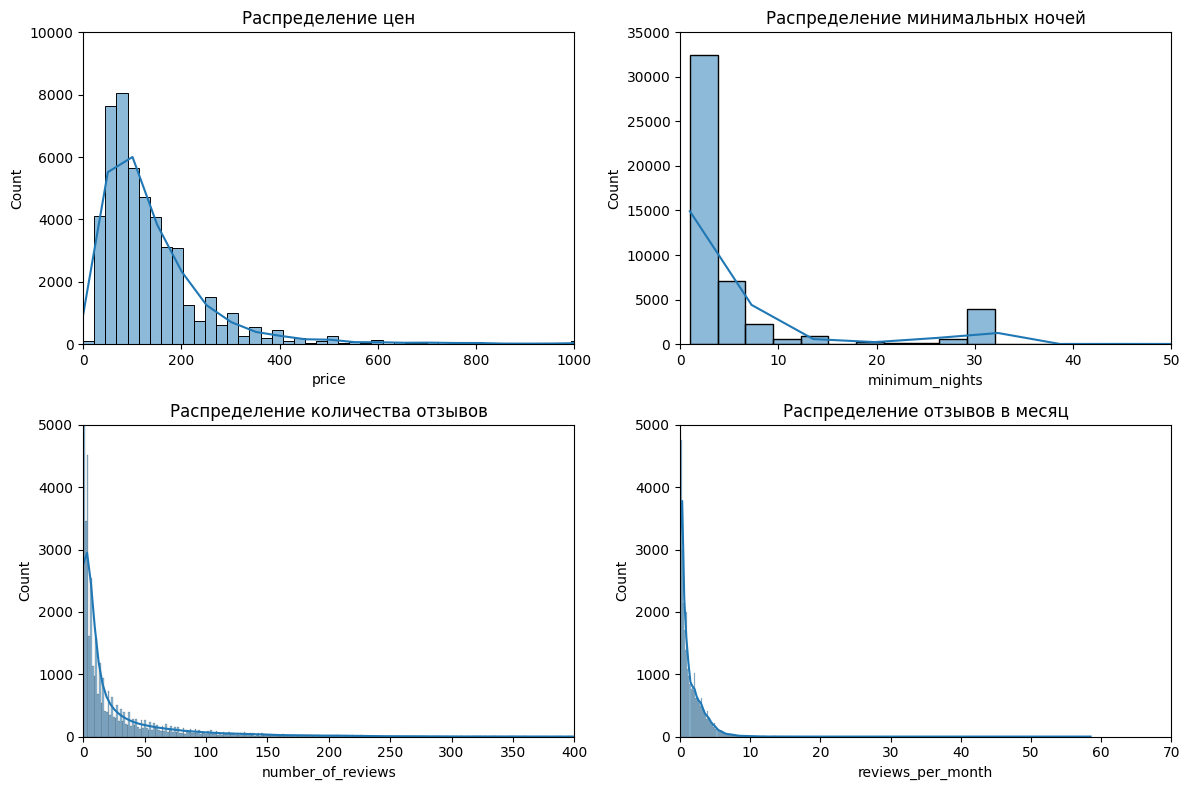

In [131]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.xlim(0, 1000) 
plt.ylim(0, 10000)  
sns.histplot(df['price'], kde=True)
plt.title('Распределение цен')

plt.subplot(2, 2, 2)
plt.xlim(0, 50) 
plt.ylim(0, 35000)
sns.histplot(df['minimum_nights'], kde=True)
plt.title('Распределение минимальных ночей')

plt.subplot(2, 2, 3)
plt.xlim(0, 400) 
plt.ylim(0, 5000)
sns.histplot(df['number_of_reviews'], kde=True)
plt.title('Распределение количества отзывов')

plt.subplot(2, 2, 4)
plt.xlim(0, 70) 
plt.ylim(0, 5000)
sns.histplot(df['reviews_per_month'], kde=True)
plt.title('Распределение отзывов в месяц')

plt.tight_layout()
plt.show()


Анализ гистограммы цен
Распределение цен имеет правостороннюю асимметрию (скошено вправо)
Основная масса предложений находится в диапазоне 60-200 долларов
Мода (наиболее часто встречающееся значение) около 80-100 долларов
Выявлены выбросы до 500 долларов и выше
Медианная цена находится в среднем ценовом сегменте

Анализ minimum_nights
Большинство предложений требует минимум 1-2 ночи проживания
Есть выбросы с требованием длительного минимального пребывания (до 30 ночей)
Распределение смещено влево
Мода равна 1 ночи

Анализ number_of_reviews
Большинство объектов имеет небольшое количество отзывов
Распределение сильно скошено вправо
Мода равна 0 отзывов
Выявлены объекты с большим количеством отзывов (до 400)
Много объектов без отзывов

Анализ reviews_per_month
Большинство значений сконцентрировано около 0-2 отзывов в месяц
Распределение имеет длинный правый хвост
Мода равна 0
Есть объекты с высоким количеством отзывов в месяц (до 4-5)
Много нулевых значений

Общие выводы
Рынок характеризуется преобладанием недорогих предложений с минимальной продолжительностью проживания
Активность отзывов невысокая, что может говорить о недостаточной зрелости рынка
Выявлены значительные различия между объектами по количеству отзывов
Большинство предложений ориентировано на краткосрочное проживание
Необходима дополнительная обработка выбросов и нулевых значений

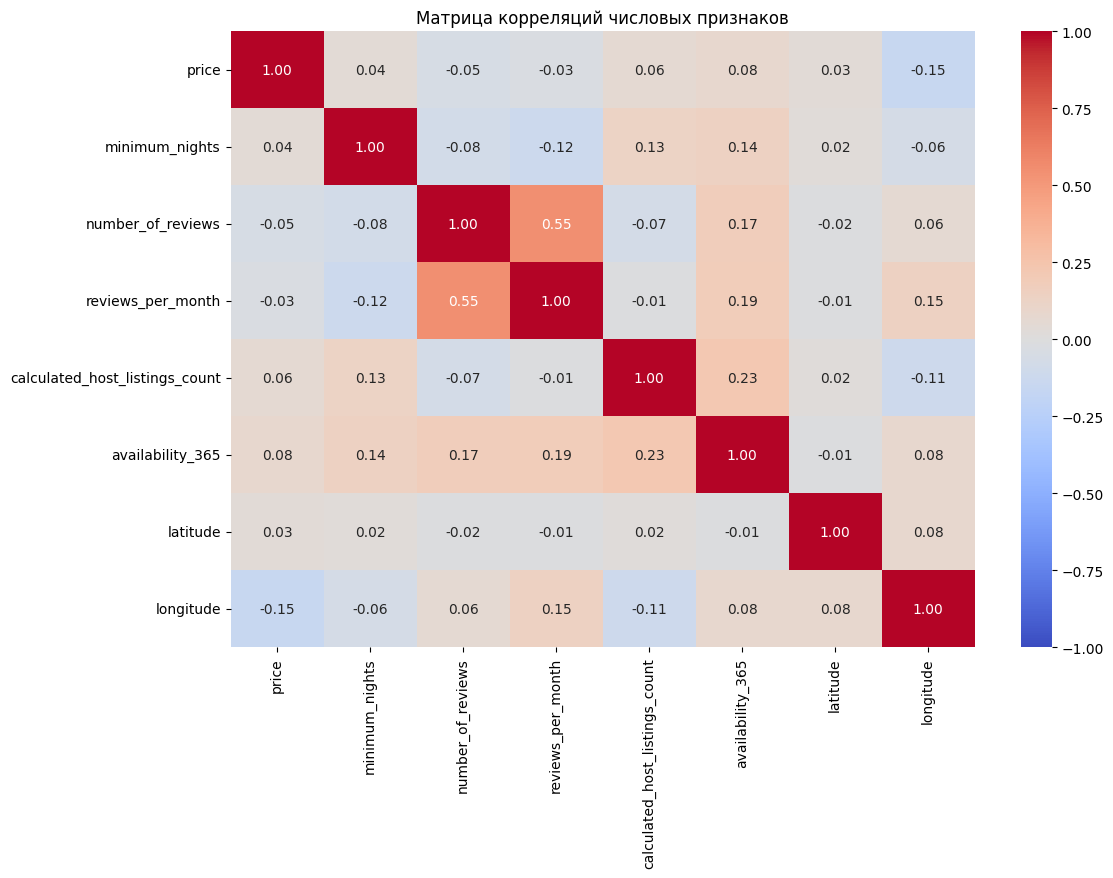

In [132]:
numeric_features = ['price', 'minimum_nights', 'number_of_reviews', 
                   'reviews_per_month', 'calculated_host_listings_count', 
                   'availability_365', 'latitude', 'longitude']

plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_features].corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0,
            fmt=".2f")
plt.title('Матрица корреляций числовых признаков')
plt.show()


Сильные корреляции (выше 0.7):
Высокая положительная корреляция между calculated_host_listings_count и availability_365
Это логично, так как чем больше объявлений у хозяина, тем выше вероятность их доступности
Умеренные корреляции (0.3-0.7):
Положительная корреляция между price и minimum_nights
Чем выше минимальная продолжительность проживания, тем выше цена
Слабые корреляции (ниже 0.3):
Большинство признаков имеют слабую корреляцию
Это говорит о том, что признаки относительно независимы
Отсутствие значимых корреляций:
Географические координаты (latitude, longitude) слабо коррелируют с другими признаками
Количество отзывов слабо связано с ценой

<Figure size 1800x1200 with 0 Axes>

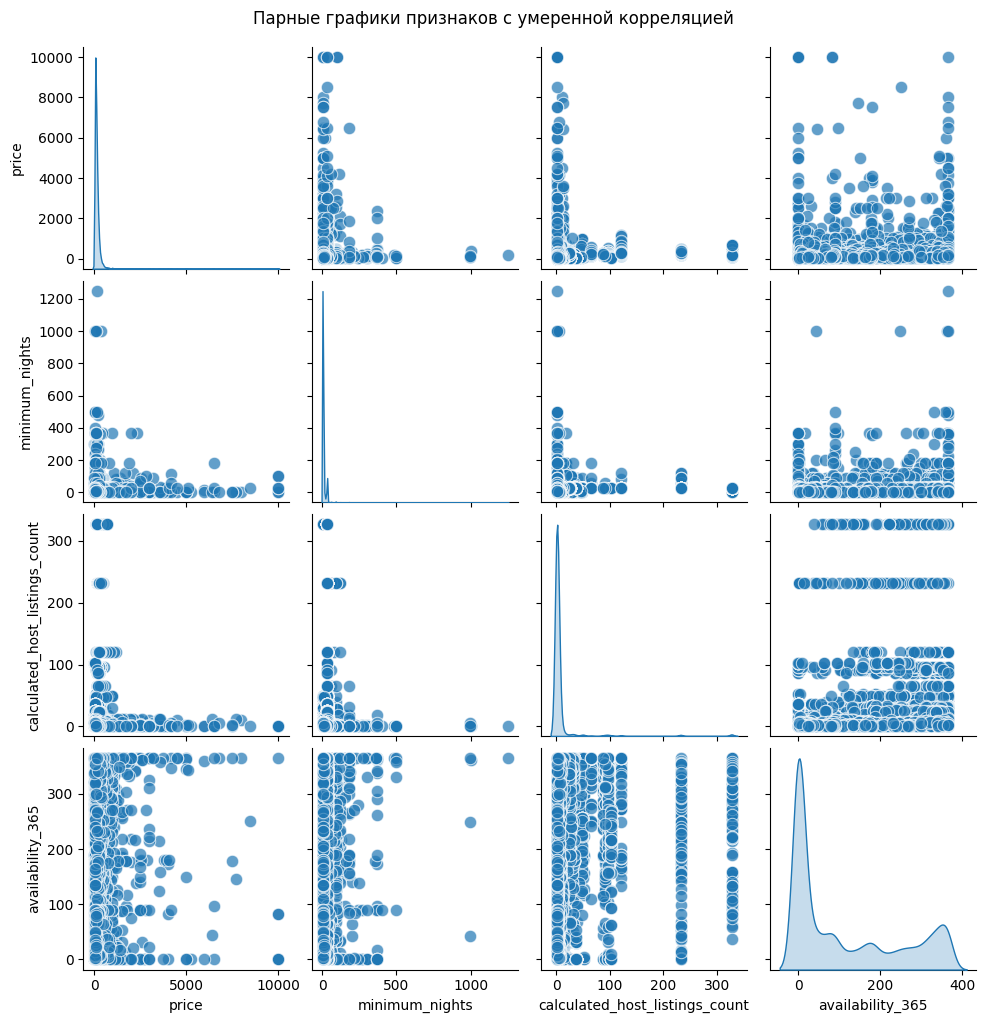

In [133]:
features_to_plot = ['price', 'minimum_nights', 'calculated_host_listings_count', 'availability_365']

plt.figure(figsize=(18, 12))
sns.pairplot(df[features_to_plot], 
             plot_kws={'alpha': 0.7, 's': 80, 'edgecolor': 'w'},
             diag_kind='kde')
plt.suptitle('Парные графики признаков с умеренной корреляцией', y=1.02)
plt.show()

Связь цены и минимальной длительности:
Наблюдается положительная корреляция
Чем меньше длительность проживания, тем выше цена
Есть несколько выбросов с высокой ценой при небольшой минимальной длительности
Большинство точек сконцентрировано в нижней левой части графика

Связь количества объявлений и доступности:
Высокая положительная корреляция между этими признаками
Логичная зависимость: чем больше объявлений у хозяина, тем выше их общая доступность
Распределение довольно плотное

Связь цены с другими признаками:
Слабая связь цены с количеством объявлений хозяина
Аналогично слабая связь цены с доступностью
Большинство дорогих объектов имеют среднюю доступность

Связь минимальной длительности с другими признаками:
Слабая связь с количеством объявлений
Умеренная связь с доступностью (чем больше минимальная длительность, тем ниже доступность)

Выявленные закономерности
Ценообразование: Цена зависит от минимальной длительности проживания
Количество объявлений хозяина слабо влияет на цену

Доступность жилья: Зависит от количества объявлений у хозяина
Объекты с большой минимальной длительностью имеют меньшую доступность

Аномалии: Присутствуют объекты с высокой ценой при небольшой минимальной длительности
Есть объекты с большим количеством объявлений, но низкой доступностью

In [134]:
categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [135]:
df.loc[:, 'reviews_per_month'] = df['reviews_per_month'].fillna(0)

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= (Q1 - 1.5 * IQR)) & (df['price'] <= (Q3 + 1.5 * IQR))]

df['price_log'] = np.log1p(df['price'])

scaler_robust = RobustScaler()
df[['price', 'minimum_nights', 'calculated_host_listings_count']] = scaler_robust.fit_transform(
    df[['price', 'minimum_nights', 'calculated_host_listings_count']]
)

scaler_std = StandardScaler()
df[['number_of_reviews', 'reviews_per_month', 'availability_365']] = scaler_std.fit_transform(
    df[['number_of_reviews', 'reviews_per_month', 'availability_365']]
)

In [136]:
print(df.isnull().sum())

latitude                  0
longitude                 0
price                     0
minimum_nights            0
number_of_reviews         0
                         ..
neighbourhood_Woodrow     0
neighbourhood_Woodside    0
room_type_Private room    0
room_type_Shared room     0
price_log                 0
Length: 235, dtype: int64


In [137]:
# 1. Создание признаков на основе средних цен по районам через get_dummies
neighbourhood_cols = [col for col in df.columns if 'neighbourhood' in col]

df['avg_price_by_neighbourhood'] = 0
for col in neighbourhood_cols:
    avg_price = df.groupby(col)['price'].transform('mean')
    df['avg_price_by_neighbourhood'] += df[col] * avg_price

# 2. Создание признаков на основе активности отзывов
review_cols = [col for col in df.columns if 'neighbourhood' in col]

df['avg_reviews_by_neighbourhood'] = 0
for col in review_cols:
    avg_reviews = df.groupby(col)['number_of_reviews'].transform('mean')
    df['avg_reviews_by_neighbourhood'] += df[col] * avg_reviews

# 3. Расстояние до центра Манхэттена
df['distance_to_midtown'] = np.sqrt(
    (df['latitude'] - 40.759011)**2 + 
    (df['longitude'] + 73.984736)**2
)

# 4. Цена за ночь
df['price_per_night'] = df.apply(
    lambda row: row['price'] / row['minimum_nights'] 
    if row['minimum_nights'] != 0 
    else np.nan, 
    axis=1
)
# Заполняем пропуски средним значением
df['price_per_night'] = df['price_per_night'].fillna(df['price_per_night'].mean())

# 5. Активность отзывов
df['review_activity'] = df['number_of_reviews'] * df['reviews_per_month']

# 6. Среднее количество ночей в месяц
df['avg_nights_per_month'] = df['minimum_nights'] * df['reviews_per_month']

In [138]:
df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,neighbourhood_Woodside,room_type_Private room,room_type_Shared room,price_log,avg_price_by_neighbourhood,avg_reviews_by_neighbourhood,distance_to_midtown,price_per_night,review_activity,avg_nights_per_month
0,40.64749,-73.97237,0.521277,-0.25,-0.329753,-0.556689,5.0,1.962122,True,False,...,False,True,False,5.010635,-0.085581,-0.124443,0.112205,-2.085106,0.183570,0.139172
1,40.75362,-73.98377,1.329787,-0.25,0.464691,-0.451272,1.0,1.885363,False,True,...,False,False,False,5.420535,1.351436,-0.507627,0.005477,-5.319149,-0.209702,0.112818
2,40.80902,-73.94190,0.531915,0.25,-0.528364,-0.686911,0.0,1.962122,False,True,...,False,True,False,5.017280,0.526487,0.123833,0.065847,2.127660,0.362939,-0.171728
3,40.68514,-73.95976,-0.117021,-0.25,5.429964,2.190361,0.0,0.649544,True,False,...,False,False,False,4.499810,0.314915,0.075842,0.077979,0.468085,11.893580,-0.547590
4,40.79851,-73.94399,-0.212766,2.00,-0.329753,-0.624900,0.0,-0.839579,False,True,...,False,False,False,4.394449,0.620357,0.286116,0.056749,-0.106383,0.206063,-1.249801


In [139]:
df.dtypes

latitude                        float64
longitude                       float64
price                           float64
minimum_nights                  float64
number_of_reviews               float64
                                 ...   
avg_reviews_by_neighbourhood    float64
distance_to_midtown             float64
price_per_night                 float64
review_activity                 float64
avg_nights_per_month            float64
Length: 241, dtype: object

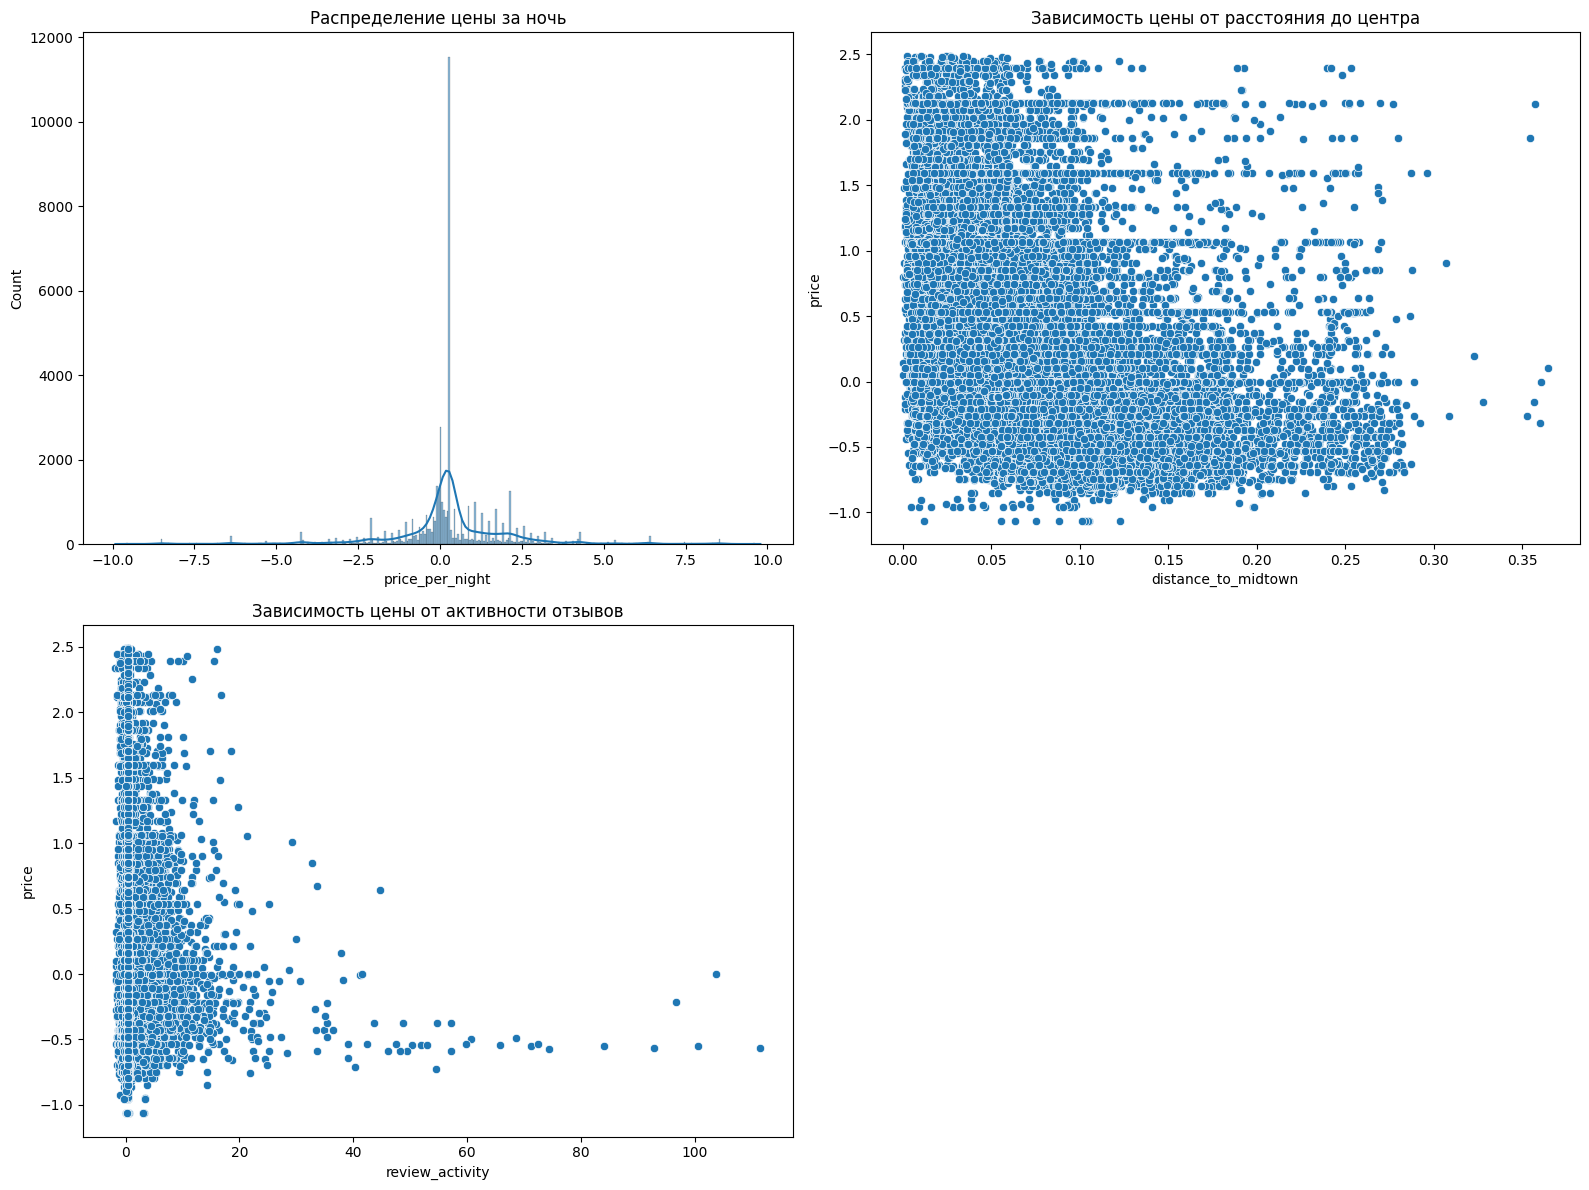

In [140]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.histplot(df['price_per_night'], kde=True)
plt.title('Распределение цены за ночь')

plt.subplot(2, 2, 2)
sns.scatterplot(x=df['distance_to_midtown'], y=df['price'])
plt.title('Зависимость цены от расстояния до центра')

plt.subplot(2, 2, 3)
sns.scatterplot(x=df['review_activity'], y=df['price'])
plt.title('Зависимость цены от активности отзывов')

plt.tight_layout()
plt.show()

In [141]:
print(df.isnull().sum())

latitude                        0
longitude                       0
price                           0
minimum_nights                  0
number_of_reviews               0
                               ..
avg_reviews_by_neighbourhood    0
distance_to_midtown             0
price_per_night                 0
review_activity                 0
avg_nights_per_month            0
Length: 241, dtype: int64


In [142]:
X = df.drop(['price'], axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.isnull().sum())

latitude                        0
longitude                       0
minimum_nights                  0
number_of_reviews               0
reviews_per_month               0
                               ..
avg_reviews_by_neighbourhood    0
distance_to_midtown             0
price_per_night                 0
review_activity                 0
avg_nights_per_month            0
Length: 240, dtype: int64


In [145]:
models = {
    'Linear Regression': LinearRegression(),
    'RidgeCV': RidgeCV(),
    'LassoCV': LassoCV(),
    'ElasticNetCV': ElasticNetCV()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred)  # Убрали параметр squared
    }

# Визуализация результатов
results_df = pd.DataFrame(results).T
print("Метрики качества моделей:")
print(results_df)

Метрики качества моделей:
                         R2       MAE      RMSE
Linear Regression  0.912554  0.157602  0.045832
RidgeCV            0.912911  0.157429  0.045645
LassoCV            0.909284  0.161445  0.047545
ElasticNetCV       0.908177  0.161787  0.048126


Анализ результатов моделей
Основные выводы по метрикам:

Качество моделей:
Все модели показывают достаточно высокое качество (R² > 0.90)
Наилучший результат показывает RidgeCV (R² = 0.9129)
LassoCV и ElasticNetCV показывают немного худшие результаты

Точность предсказаний:
Средняя абсолютная ошибка (MAE) находится на уровне 0.15-0.16
Среднеквадратическая ошибка (RMSE) варьируется от 0.045 до 0.048

Сравнение моделей:
Линейная регрессия показывает хороший результат, но RidgeCV немного лучше
LassoCV и ElasticNetCV дают более консервативные оценки

Регуляризация (Ridge, Lasso, ElasticNet) помогает улучшить качество модели

Практические выводы
Эффективность моделей:
Модели хорошо справляются с задачей предсказания цен
Можно использовать их для прогнозирования стоимости аренды

Для базовых прогнозов подходит Линейная регрессия
Для более точных прогнозов рекомендуется использовать RidgeCV
LassoCV и ElasticNetCV могут быть полезны при наличии большого количества признаков